<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Kaggle Mastery: Summarize Kaggle solution write-ups</h1>
</div>


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Installing Libraries</h1>
</div>


In [1]:
!pip install -U transformers
!pip install accelerate
!pip install -i https://pypi.org/simple/ bitsandbytes
!pip install hf_transfer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.38.2
    Uninstalling transformers-4.38.2:
      Successfully uninstalled transformers-4.38.2
Looking in indexes: https://pypi.org/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 52.1 MB/s eta 0:00:00


### **`Accelerate:`**
- `Purpose`: Model acceleration library.This libaray developed by the Hugging Face
- `Usage`: Offers tools to accelerate model training and inference, often leveraging hardware accelerators like GPUs.

### **`Transformers`**
- `Purpose`: This libaray is the state of art open Models.
- `Usage`: Offers access to pretrained transformer models for tasks like text generation, translation, and question answering.

### **`Hf_Transfers:`**
- `Purpose`: This library  relates to model transfer learning or model fine-tuning with the Hugging Face transformers library.
- `Usage`: It simplifies the process of Transfer Knowledge

### **Transformers Libarary:[Transformers](https://huggingface.co/docs/transformers/index)**

### **Accelerate Libarary: [Accelerate](https://huggingface.co/docs/accelerate/en/index)**

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Importing Libararies</h1>
</div>


In [2]:
# Import the required libararies
import numpy as np 
import pandas as pd 
from bs4 import BeautifulSoup
import plotly.express as px
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.graph_objs as go
from mpl_toolkits.mplot3d import Axes3D
import textwrap
from IPython.display import Markdown
#checking GPU 
import torch
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import BitsAndBytesConfig
from IPython.display import Markdown, display
import textwrap
# import tabulate
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

 **`Beautiful Soup:`**
 
- `Purpose:` It is used for Web Scrapping Purpose.documents
- `Usage:`  It is also used parsing HTML and XML 

**`Pandas`**
- `Purpose`: Data manipulation and analysis library.
- `Usage`: Used for handling structured data, such as CSV files, SQL tables, and Excel sheets, providing data structures like DataFrame.


**`matplotlib:`**
- `Purpose`: Data visualization libarary.
- `Usage`: Used to make the unique plots

**`Numpy`**
- `Purpose`: Numerical computing library.
- `Usage`: Provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions.

**`plotly:`**
- `Purpose`:It is a Data Visualization libarary
- `Usage` :It is used to create the interactive plots

**`tabulate:`** It is used for displaying the Data in visually appealing manner

**`The AutoModelForCausalLM.from_pretrained() function:`** loads a pretrained language model for causal language modeling.

In [3]:
if torch.cuda.is_available():
  print("GPU available!")
else:
  print("GPU not detected. Using CPU...")

GPU available!


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Enable Huggingface hub_transfer</h1>
</div>


In [4]:
# Enable Huggingface hub_transfer for model_gemma sharing and versions
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Load and Display the kaggle winning solution Dataset</h1>
</div>


In [5]:
sol=pd.read_csv("/kaggle/input/kaggle-winning-solutions-methods/kaggle_winning_solutions_methods_detail.csv")
# Lets Display First Five Rows
sol.head()

,link,place,competition_name,prize,team,kind,metric,year,nm,writeup,num_tokens,methods,cleaned_methods
0,https://www.kaggle.com/c/asl-signs/discussion/...,2,Google - Isolated Sign Language Recognition,"$100,000","1,165",Research,PostProcessorKernelDesc,2023,406306,<h2>TLDR</h2>\n<p>We used an approach similar ...,2914,EfficientNet-B0,CNNs
1,https://www.kaggle.com/c/asl-signs/discussion/...,2,Google - Isolated Sign Language Recognition,"$100,000","1,165",Research,PostProcessorKernelDesc,2023,406306,<h2>TLDR</h2>\n<p>We used an approach similar ...,2914,Data Augmentation,Data Augmentation
2,https://www.kaggle.com/c/asl-signs/discussion/...,2,Google - Isolated Sign Language Recognition,"$100,000","1,165",Research,PostProcessorKernelDesc,2023,406306,<h2>TLDR</h2>\n<p>We used an approach similar ...,2914,Normalization,Preprocessing
3,https://www.kaggle.com/c/asl-signs/discussion/...,2,Google - Isolated Sign Language Recognition,"$100,000","1,165",Research,PostProcessorKernelDesc,2023,406306,<h2>TLDR</h2>\n<p>We used an approach similar ...,2914,Interpolation,Interpolation
4,https://www.kaggle.com/c/asl-signs/discussion/...,2,Google - Isolated Sign Language Recognition,"$100,000","1,165",Research,PostProcessorKernelDesc,2023,406306,<h2>TLDR</h2>\n<p>We used an approach similar ...,2914,BERT,Transformers


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Load and Display the all completed kaggle competitions Dataset</h1>
</div>


In [6]:
kaggle_sol=pd.read_csv("/kaggle/input/kaggles-all-completed-competition-dataset/kaggle comp_submission.csv")
# Lets Display First Five Rows
kaggle_sol.head()

,comp_name,comp_Reward,comp_link,teams,competitors,Entries,Tag,desc,code_link,start_date,start_month,start_year,final_date,final_month,final_year
0,Tabular Playground Series - Sep 2022,Swag,https://www.kaggle.com/competitions/tabular-pl...,1381,1447,13085,tabular data,The competing Kaggle merchandise stores we saw...,https://www.kaggle.com/code/elem3ntary/tps-sep...,1,Sep,2022,1,Oct,2022
1,AI Village Capture the Flag @ DEFCON,25000,https://www.kaggle.com/competitions/ai-village...,668,668,4235,games,Help Henry Hacker get to Homecoming during DEF...,https://www.kaggle.com/code/tatamikenn/defcon3...,12,Aug,2022,12,Sep,2022
2,Tabular Playground Series - Aug 2022,Swag,https://www.kaggle.com/competitions/tabular-pl...,1888,1972,21790,tabular data,The August 2022 edition of the Tabular Playgro...,https://www.kaggle.com/code/neesham/nlp-for-be...,1,Aug,2022,1,Sep,2022
3,RSNA 2022 Cervical Spine Fracture Detection,30000,https://www.kaggle.com/competitions/rsna-2022-...,883,1108,12871,image data,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022
4,Google Universal Image Embedding,50000,https://www.kaggle.com/competitions/google-uni...,1022,1217,20984,image data,Welcome to the Universal Image Embedding compe...,https://www.kaggle.com/code/mozattt/ml-maratho...,11,Jul,2022,4,Oct,2022


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Merge the Datasets</h1>
</div>


## **Datasets Links:**
We can access both of the datasets through these links:

#### **1. [kaggles-all-completed-competition-dataset](https://www.kaggle.com/datasets/soumendraprasad/kaggles-all-completed-competition-dataset)**

#### **2. [kaggle-winning-solutions-methods](https://www.kaggle.com/datasets/thedrcat/kaggle-winning-solutions-methods)**


In [7]:
# Read the first file
sol = pd.read_csv("/kaggle/input/kaggle-winning-solutions-methods/kaggle_winning_solutions_methods_detail.csv")

# Read the second file
kaggle_sol = pd.read_csv("/kaggle/input/kaggles-all-completed-competition-dataset/kaggle comp_submission.csv")

# Rename the column 'comp_name' to 'competition_name' in the second dataframe
kaggle_sol.rename(columns={'comp_name': 'competition_name'}, inplace=True)

# Perform the merge operation
merged_data = pd.merge(sol, kaggle_sol, on="competition_name", how="inner")

# Display the merged data
merged_data.head()


,link,place,competition_name,prize,team,kind,metric,year,nm,writeup,...,Entries,Tag,desc,code_link,start_date,start_month,start_year,final_date,final_month,final_year
0,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,"$30,000",883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,12871,image data,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022
1,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,"$30,000",883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,12871,image data,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022
2,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,"$30,000",883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,12871,image data,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022
3,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,"$30,000",883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,12871,image data,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022
4,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,"$30,000",883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,12871,image data,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Merged Data Columns</h1>
</div>


In [8]:
merged_data.columns

Index(['link', 'place', 'competition_name', 'prize', 'team', 'kind', 'metric',
       'year', 'nm', 'writeup', 'num_tokens', 'methods', 'cleaned_methods',
       'comp_Reward', 'comp_link', 'teams', 'competitors', 'Entries', 'Tag',
       'desc', 'code_link', 'start_date', 'start_month', 'start_year',
       'final_date', 'final_month', 'final_year'],
      dtype='object')

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Merged data structure</h1>
</div>


In [9]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38471 entries, 0 to 38470
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   link              38471 non-null  object
 1   place             38471 non-null  int64 
 2   competition_name  38471 non-null  object
 3   prize             38471 non-null  object
 4   team              38471 non-null  object
 5   kind              38471 non-null  object
 6   metric            38471 non-null  object
 7   year              38471 non-null  int64 
 8   nm                38471 non-null  int64 
 9   writeup           38471 non-null  object
 10  num_tokens        38471 non-null  int64 
 11  methods           38471 non-null  object
 12  cleaned_methods   38471 non-null  object
 13  comp_Reward       38471 non-null  object
 14  comp_link         38471 non-null  object
 15  teams             38471 non-null  int64 
 16  competitors       38471 non-null  int64 
 17  Entries     

## **Observations:**
>* we have the two Datasets which have the csv files about kaggle competitions
>* So, we merged both of the Datasets and create the merged dataset
>* In the Merged Data 38471 Rows and 27 Columns
>* 11 Columns are of int datatype such as:place,'year', 'nm', 'num_tokens',teams,
        'competitors', 'Entries', 'start_date', 'start_year','final_date', 'final_year' 
>* 16 Columns are of object datatye such as 'link', 'place', 'competition_name','team', 'kind', 'metric', 'writeup', , 'methods', 'cleaned_methods', 'comp_Reward', 'comp_link', 'Tag','desc', 'code_link', 'start_month','final_month',

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Rename the Merged Data to df</h1>
</div>


In [10]:
# Rename merged Data to df
df = merged_data.rename(columns=lambda x: x.replace('old_column_name', 'new_column_name'))



<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Display the  Summary Statistic in Transposed Table Format Using Tabulate</h1>
</div>

In [11]:
# Display summary statistics of numerical columns in a transposed table format using tabulate
print(tabulate(df.describe().T, headers='keys', tablefmt='psql'))


+-------------+---------+-------------+-------------+-------+--------+--------+--------+--------+
|             |   count |        mean |         std |   min |    25% |    50% |    75% |    max |
|-------------+---------+-------------+-------------+-------+--------+--------+--------+--------|
| place       |   38471 |     14.0276 |    11.5984  |     1 |      5 |     10 |     19 |     59 |
| year        |   38471 |   2020.15   |     1.41807 |  2014 |   2019 |   2020 |   2021 |   2022 |
| nm          |   38471 | 191485      | 96180.6     | 10547 | 111735 | 183255 | 275360 | 365115 |
| num_tokens  |   38471 |   1400.3    |   860.966   |    39 |    806 |   1202 |   1801 |   8480 |
| teams       |   38471 |   1935.75   |  1293.03    |    24 |    943 |   1531 |   2920 |   8751 |
| competitors |   38471 |   2245.93   |  1529.89    |    29 |   1108 |   1839 |   3004 |   9787 |
| Entries     |   38471 |  35268.9    | 26518.5     |   242 |  14309 |  28222 |  46281 | 131888 |
| start_date  |   38

In [12]:
# Strip leading and trailing spaces from column headers to avoid any errors when calling the columns
df.columns = [col.strip() for col in df.columns]

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Have a sneakpeak at the duplicates</h1>
</div>


In [13]:
# Count the number of duplicate rows
num_duplicates = merged_data.duplicated().sum()

# Print the number of duplicate rows
print("Number of Duplicate Rows:", num_duplicates)


Number of Duplicate Rows: 26997


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Drop the Duplicates</h1>
</div>


In [14]:
## Remove duplicates
merged_data.drop_duplicates(inplace=True)

# Count the number of duplicate rows
num_duplicates = sol.duplicated().sum()

# Print the number of duplicate rows
print("Number of Duplicate Rows:", num_duplicates)


Number of Duplicate Rows: 33065


## **Observations:**
>* In order to observe that duplicates are present in the dataset we check how many of the duplicated rows are present in the Dataset
>* We observe that there are 33065 Rows present in the Dataset
>* Then we drop these duplicated rows in order to clean the dataset

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets have a sneakpeak at the Entries and Number of years by Stemograph</h1>
</div>


In [15]:
# Prepare the data for Streamgraph
df_stream = (
    merged_data.groupby(["year", "kind"])["Entries"]
    .sum()
    .reset_index()
    .sort_values(by=["year", "kind"])
)

# Create streamgraph plot
fig = px.area(df_stream, x="year", y="Entries", color="kind", title="Number of Entries by Competition Type over Years",
              labels={"Entries": "Number of Entries", "year": "Year"})
fig.update_layout(hovermode="x", xaxis=dict(type='category'))  # Set hover mode to compare data across competition types
fig.show()

## **Observations:**
>* By plotting the area chart of the competition year 2014-2022 we can observe that the year of competition released, and what kind of competition it is andHow many entries in competition
>* We observed that the entries in the year 2014 is 25.905k
>* In the competition year 2021 there are maximum number of entries such as 50.94434M

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Remove Non numeric character to the string and convert to int</h1>
</div>


In [16]:
# Lets replace "K" Sign of  Times Listed with the empty string 
df['prize']=df['prize'].apply(lambda x:x.replace("$","")if "K" in str(x) else x)

In [17]:
# Remove non-numeric characters from the string and then convert it to an integer
df['prize'] = df['prize'].apply(lambda x: int(''.join(filter(str.isdigit, str(x)))) if str(x).isdigit() else None)


## **Observations:**
>* In order to clean the Data and make the prize column completely neumeric we remove the non numeric character from the prize column and convert the price column to int by making it completely numeric 
>* After applying Data Cleaning the processing can be takes place easil and we can take better insights about the Data

 <div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Density Contour Plot of num_tokens vs. Entries</h1>
</div>


## **`density contour plot:`**
>* A **2D histogram contour plot**, also known as a **density contour plot**.
>* It is a 2-dimensional generalization of a histogram which resembles a contour plot 
>* It is computed by grouping a set of points specified by their x and y coordinates into bins
>* A density contour plot is a representation of the distribution of a numeric variable
>* It uses a kernel density estimate to show the probability density function of the variable 

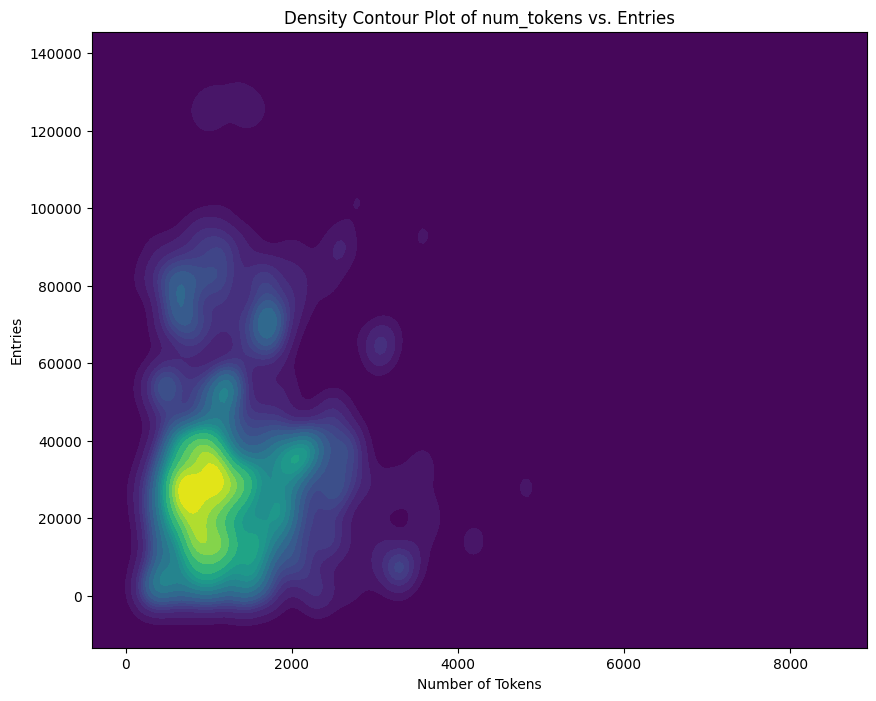

In [18]:
plt.figure(figsize=(10, 8))
sns.kdeplot(x=df['num_tokens'], y=df['Entries'], fill=True, cmap='viridis', thresh=0, levels=20)
plt.title('Density Contour Plot of num_tokens vs. Entries')
plt.xlabel('Number of Tokens')
plt.ylabel('Entries')
plt.show()


## **Observations:**
>* By plotting the Density contour plot of Number of Tokens and Entries we can observe the distribution of these columns and the Datapoints
>* In this plot the entries in between of 40000 and the 2000 Number of Tokens there are maximum density hence it represents maximum distribution at there. 
>* As in the density contour plot the High densiy area reprents the maximum number of values of both the columns are distributed there
>* The maximum density represents the maximum distribution or similarity among the columns

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Discover Insights of Multiple Variables: A Dynamic Parallel Coordinate Plot</h1>
</div>


## **Parallel plot or parallel coordinates plot:**
>* It allows to compare the feature of several individual observations ( series ) on a set of numeric variables.
>* Each vertical bar represents a variable 
>*  its ability to represent high dimensional data as a two-dimensional visualization. This means that as the data is represented in the form of a line
>* It becomes easier to pickup the trends and patterns

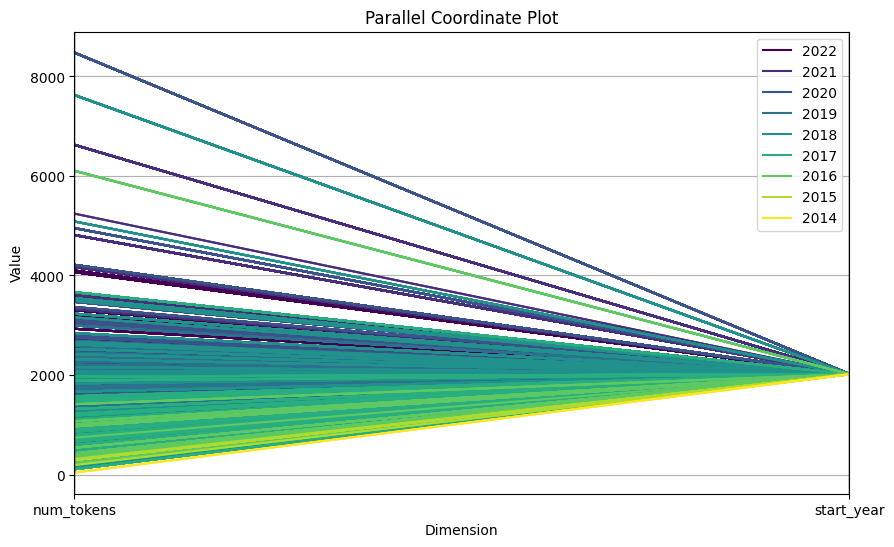

In [19]:
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Define the columns you want to include in the plot
columns_to_include = ['num_tokens','start_year', 'final_year']

# Plotting
plt.figure(figsize=(10, 6))
parallel_coordinates(df[columns_to_include], 'final_year', colormap='viridis')

# Set plot title and labels
plt.title('Parallel Coordinate Plot')
plt.xlabel('Dimension')
plt.ylabel('Value')

plt.show()


## **Observations:**
>* In the parallel coordinate plot each vertical line represents the values of the columns in the dataset or the datapoints
>* The color of the lines in this plot represents the year column
>* Parallel coordinate plot helps to visualize the relationship among different variables or columns. Hence it is used for multivariate analysis

In [20]:
# Print unique competition names to check for unexpected values
unique_competition_names = df['competition_name'].unique()[:20]  # Take only the first 10 unique competition names
print("First 20  competition names:", unique_competition_names)


First 20  competition names: ['RSNA 2022 Cervical Spine Fracture Detection'
 'Google Universal Image Embedding' 'JPX Tokyo Stock Exchange Prediction'
 'Mayo Clinic - STRIP AI' 'HuBMAP + HPA - Hacking the Human Body'
 'AI Village Capture the Flag @ DEFCON'
 'American Express - Default Prediction'
 'Feedback Prize - Predicting Effective Arguments'
 'Google Smartphone Decimeter Challenge 2022' 'Ubiquant Market Prediction'
 'Foursquare - Location Matching' 'Image Matching Challenge 2022'
 'iWildCam 2022 - FGVC9' 'Sorghum -100 Cultivar Identification - FGVC 9'
 'Hotel-ID to Combat Human Trafficking 2022 - FGVC9' 'BirdCLEF 2022'
 'GeoLifeCLEF 2022 - LifeCLEF 2022 x FGVC9'
 'H&M Personalized Fashion Recommendations'
 'NBME - Score Clinical Patient Notes'
 'Happywhale - Whale and Dolphin Identification']


In [21]:
# Group by competition name and count unique teams
teams_per_competition = df.groupby('competition_name')['team'].value_counts()

# Print the number of teams for each competition name
print("Number of teams in each competition:")
print(teams_per_competition)


Number of teams in each competition:
competition_name                             team 
2019 Data Science Bowl                       3,497    657
AI Village Capture the Flag @ DEFCON         668       39
ALASKA2 Image Steganalysis                   1,095    428
APTOS 2019 Blindness Detection               2,943    983
ASHRAE - Great Energy Predictor III          1,877    479
                                                     ... 
iMaterialist Challenge (Fashion) at FGVC5    212        3
iMaterialist Challenge (Furniture) at FGVC5  436       18
iWildCam 2020 - FGVC7                        126       78
iWildCam 2022 - FGVC9                        24         6
iWildcam 2021 - FGVC8                        42       128
Name: count, Length: 155, dtype: int64


In [22]:
# Filter rows where the team won a reward
rewarded_teams = df[df['comp_Reward'].notnull()]

# Print the rewarded teams along with the competition name and reward details
print("Teams that won rewards in each competition:")
print(rewarded_teams[['competition_name', 'team', 'comp_Reward']])


Teams that won rewards in each competition:
                                  competition_name   team comp_Reward
0      RSNA 2022 Cervical Spine Fracture Detection    883       30000
1      RSNA 2022 Cervical Spine Fracture Detection    883       30000
2      RSNA 2022 Cervical Spine Fracture Detection    883       30000
3      RSNA 2022 Cervical Spine Fracture Detection    883       30000
4      RSNA 2022 Cervical Spine Fracture Detection    883       30000
...                                            ...    ...         ...
38466               Diabetic Retinopathy Detection    661      100000
38467         Crowdflower Search Results Relevance  1,326       20000
38468                Display Advertising Challenge    718       16000
38469                Display Advertising Challenge    718       16000
38470                Display Advertising Challenge    718       16000

[38471 rows x 3 columns]


>* By applying this code we can observed that how much reward the each competition have and which team wins that reward

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Parallel Sets Plot of Teams, Competitors, and Tags Columns</h1>
</div>


 ## **parallel sets plot:**
 >* A **parallel sets plot** is a representation of various dimensions with relationships
 >* Each dimension has a horizontal line, which divides into the number of categories of that dimension
 >* The width of the bar represents the higher value of that category
 >* In this plot each variable is given an axis and all the axes are placed parallel to each other

In [23]:
# Map each unique category in 'Tag' to a color
color_mapping = {tag: f'rgb({i * 30}, {i * 50}, {i * 70})' for i, tag in enumerate(df['Tag'].unique())}

# Apply the color mapping to create a color column
df['Color'] = df['Tag'].map(color_mapping)

# Plot the parallel categories plot
fig = px.parallel_categories(df, color='Color')
fig.update_layout(title='Parallel Sets Plot of teams, competitors, and Tag', width=800, height=600)
fig.show()

>* This plot represents the correlation among the variables such as 'teams', 'competitors', and 'Tag'
>* The overlapping lines represents the category or the values occurs simultaneously

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Have a look at Pairwise relationships between num_tokens, Entries, and comp_Reward</h1>
</div>


## **pairplot:**
>* A pairplot a pairwise relationships in a dataset. 
>* The pairplot function creates a grid of Axes
>*  Pairplot allows us to plot pairwise relationships between variables within a dataset
>* The relationship of a variable with itself is displayed as a histogram, and its correlation to other variables is displayed as a scatterplot

<Figure size 1500x800 with 0 Axes>

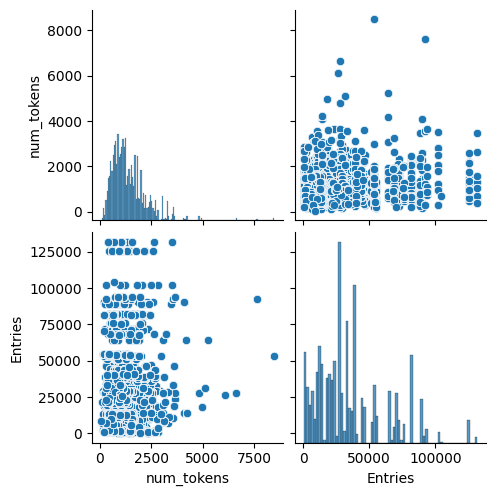

In [24]:
plt.figure(figsize=(15, 8))
sns.pairplot(df[['num_tokens', 'Entries', 'comp_Reward']])
plt.xticks(rotation=45)
# plt.title('Pairwise relationships between num_tokens, Entries, and comp_Reward')
plt.show()


## **Observations:**
>* The histogram in pair plot represents the Distribution of Variables
>* The scatter plot represents the relationship among diffrent variables
>* In scatter plot the upward trend represents the strong correlation
>* while the lower Trend shows the low correlation

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Have a Look at Ridge plot</h1>
</div>


## **Ridge plot:**
>* Ridge plot are partially overlapping line plot that are likemountain range.
>* It can be  useful for visualizing changes in distributions over time or space
>* In a ridge plot, the x-axis represents the variable being analyzed, while the y-axis represents the density of data at each value of the variable.
>* The density plot for each group or variable is displayed as a ridge, with the ridges stacked on top of each other.

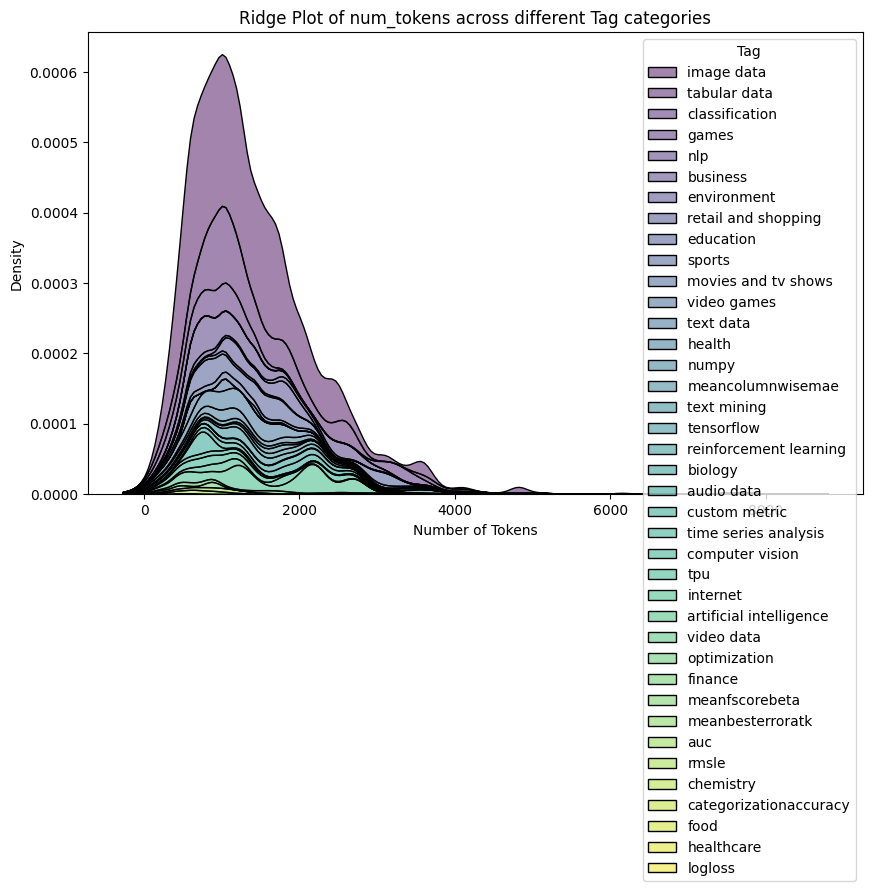

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='num_tokens', hue='Tag', fill=True, alpha=0.5, multiple='stack', palette='viridis')
plt.title('Ridge Plot of num_tokens across different Tag categories')
plt.xlabel('Number of Tokens')
plt.ylabel('Density')
plt.show()


## **Observations:**
>* We create The Ridge plot to visualize the distribution of num_token variable across the various Tag categories
>* The filled area represents the density 
>* Hence the filled area and the overlapping lines represents the density of the num_tokens across diffrent categories

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Have a Sneak peak at the correlation matrix</h1>
</div>


## **Correlation matrix:**
>* A correlation matrix is used to evaluate the relationship between two variables in a data set.
>* The matrix is a table in which every cell contains a correlation coefficient 
>* 1 is considered a strong relationship between variables, 0 a neutral relationship and -1 a not strong relationship.
>* Numtoken have strong correlation with itself
>* The value 0.05 of the correlation matrix between num_Token and Entries represents the weak positive correlation among them 

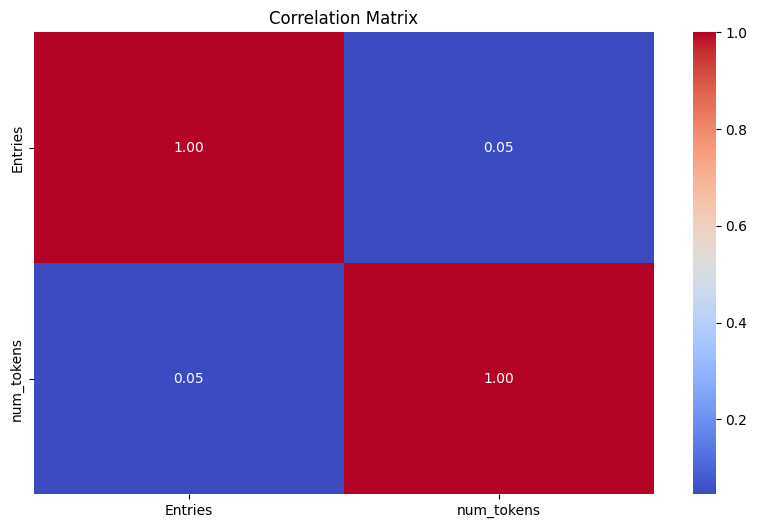

In [26]:
correlation_matrix = df[[ 'Entries', 'num_tokens']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Polar Bar Plot of num_tokens across different Tag categories</h1>
</div>


## **Polar Bar charts:**
>* Polar Bar charts are  best used for displaying multivariate observations with an arbitrary number of variables in the form of a two-dimensional chart
>* In this chart, the bars are arranged in a polar coordinate system
>* the differences between categories and groups are made visually evident through the length of their segments and bars.

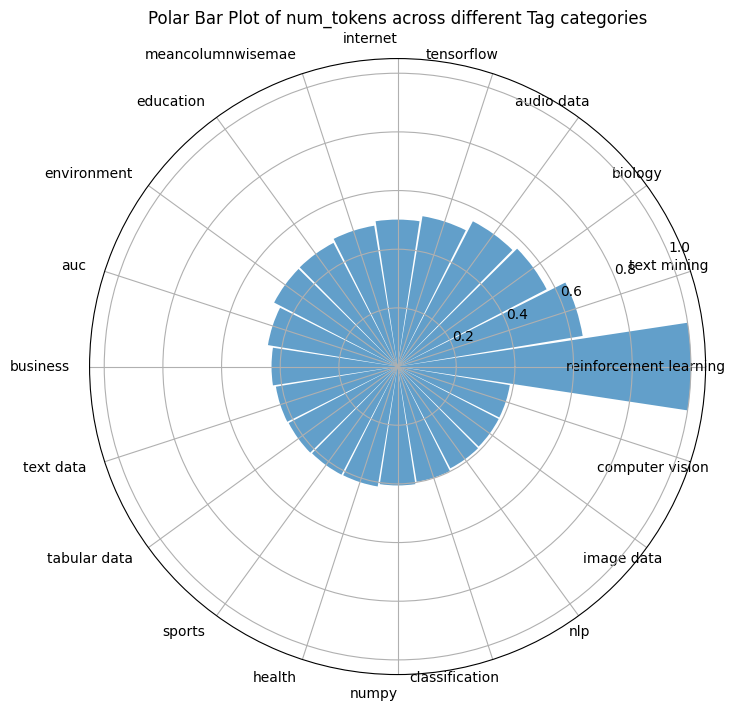

In [27]:
# Assuming 'Tag' is a categorical variable and 'num_tokens' is numerical
categories = df['Tag'].unique()

# Aggregate less frequent categories into broader groups
tag_counts = df['Tag'].value_counts()
threshold = 100  # Adjust this threshold based on your data
frequent_tags = tag_counts[tag_counts >= threshold].index
df['Tag'] = np.where(df['Tag'].isin(frequent_tags), df['Tag'], 'Other')
categories = df['Tag'].unique()

# Sort categories by the mean value of 'num_tokens'
category_means = df.groupby('Tag')['num_tokens'].mean()
categories = category_means.sort_values(ascending=False).index

num_categories = len(categories)

# Adjust the number of categories displayed
max_categories = 20  # Adjust this based on your preference
categories = categories[:max_categories]
num_categories = len(categories)

theta = np.linspace(0, 2*np.pi, num_categories, endpoint=False)
# We don't need to close the plot

r = [category_means[cat] for cat in categories]
r_max = max(r)  # Scale the radius to make it fit in the plot
r = [val / r_max for val in r]

plt.figure(figsize=(16, 8))  # Adjust the figure size
ax = plt.subplot(111, polar=True)
bars = ax.bar(theta, r, width=0.3, alpha=0.7)

plt.title('Polar Bar Plot of num_tokens across different Tag categories')

# Adjusting rotation of labels and adding grid lines
ax.set_xticks(theta)
ax.set_xticklabels(categories, rotation=50, ha='right')
ax.yaxis.grid(True)  # Add grid lines for better readability

plt.show()


## **Observations:**
>* Thee mean values are scaled at radial coordinates
>* A Polar Bar Plot is created using plt.subplot(111, polar=True) in order to oberve the polar projection.
>* Bars are plotted using ax.bar(theta, r, width=0.3, alpha=0.7) Hence the angular coordinates are represented as (theta) and scaled radial coordinates are represented as (r).

<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets have a sneakpeak at 3D scatter plot</h1>
</div>


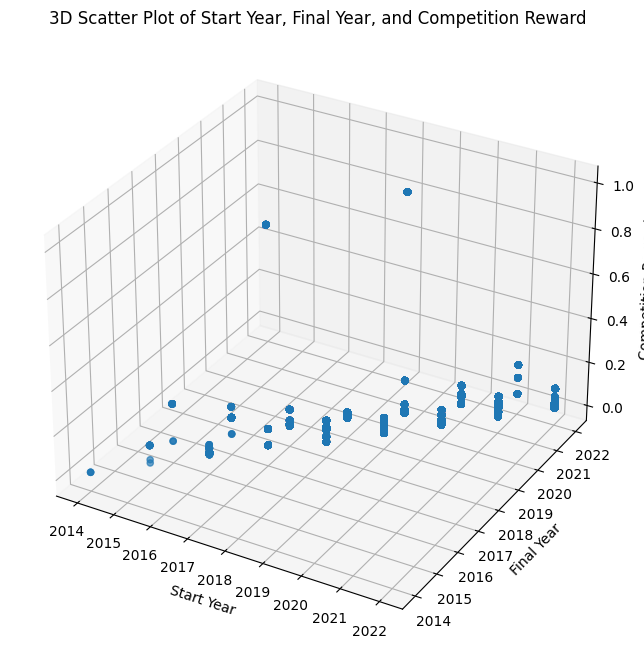

In [28]:
# Convert columns to numeric data type
df['start_year'] = pd.to_numeric(df['start_year'], errors='coerce')
df['final_year'] = pd.to_numeric(df['final_year'], errors='coerce')
df['comp_Reward'] = pd.to_numeric(df['comp_Reward'], errors='coerce')

# Handle missing values
df.dropna(subset=['start_year', 'final_year', 'comp_Reward'], inplace=True)

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['start_year'], df['final_year'], df['comp_Reward'])
ax.set_xlabel('Start Year')
ax.set_ylabel('Final Year')
ax.set_zlabel('Competition Reward')
plt.title('3D Scatter Plot of Start Year, Final Year, and Competition Reward')
plt.show()


>* The 3D scatter plot is used to visualize the relationship among the variables in 3D space


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Have a look at the writeups </h1>
</div>

In [29]:
html_sol = df["writeup"][0]
html_sol

'<p>Thanks to Kaggle and RSNA for such a great competition, we are very happy to have finished second. From this complex game, we tried to find the most concise and efficient solution, and gained a lot of knowledge. It was also one of the most hard-drive intensive competitions I\'ve ever seen, and we wasted time loading data because we didn\'t have enough space to save the high-resolution pseudo-label voxel.</p>\n<p>To cut to the chase, our solution consists of two stages, and use 2.5D CNNs, which we learned from <a href="https://www.kaggle.com/awsaf49" target="_blank">@Awsaf</a> in UWM <a href="https://www.kaggle.com/code/awsaf49/uwmgi-2-5d-train-pytorch" target="_blank">UWMGI: 2.5D Train [PyTorch] | Kaggle</a> </p>\n<p>stage1： 2.5D CNN + Unet for Segmentation </p>\n<p>stage2： CNN + BiGRU + Attention for Classification </p>\n<h2>Stage 1</h2>\n<p>First, we used the 87 studies of segmentation samples provided by the organizers . We recreated the mask labels according to the following me


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Data Cleaning </h1>
</div>

In [30]:

html_sol = df["writeup"][0]
soup = BeautifulSoup(html_sol, 'html.parser')
text = soup.get_text()

# extracted text
print(text[:400])

Thanks to Kaggle and RSNA for such a great competition, we are very happy to have finished second. From this complex game, we tried to find the most concise and efficient solution, and gained a lot of knowledge. It was also one of the most hard-drive intensive competitions I've ever seen, and we wasted time loading data because we didn't have enough space to save the high-resolution pseudo-label v


### **Beautiful Soup:**
>* `Beautiful Soup is a Python library that makes it easy to scrape information from web pages. It sits atop an HTML or XML parser and provides Pythonic idioms for iterating, searching, and modifying the parse tree`
 >* `Beautiful Soup started out as an HTML parser that would take tag soup and make it beautiful, or at least workable`
### **[BeautifulSoup Libarary](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)**

In [31]:
#extract text from HTML write-up
def extract_text(html_sol):
    soup = BeautifulSoup(html_sol, 'html.parser')
    
    text = soup.get_text()
    return text

df['writeup_text'] = df['writeup'].apply(extract_text)

df.head()

,link,place,competition_name,prize,team,kind,metric,year,nm,writeup,...,desc,code_link,start_date,start_month,start_year,final_date,final_month,final_year,Color,writeup_text
0,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,None,883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022,"rgb(0, 0, 0)",Thanks to Kaggle and RSNA for such a great com...
1,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,None,883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022,"rgb(0, 0, 0)",Thanks to Kaggle and RSNA for such a great com...
2,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,None,883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022,"rgb(0, 0, 0)",Thanks to Kaggle and RSNA for such a great com...
3,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,None,883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022,"rgb(0, 0, 0)",Thanks to Kaggle and RSNA for such a great com...
4,https://www.kaggle.com/c/rsna-2022-cervical-sp...,2,RSNA 2022 Cervical Spine Fracture Detection,None,883,Featured,Weighted Mean Columnwise Log Loss,2022,365115,<p>Thanks to Kaggle and RSNA for such a great ...,...,Goal of the Competition\nOver 1.5 million spin...,https://www.kaggle.com/code/haqishen/rsna-2022...,28,Jul,2022,21,Oct,2022,"rgb(0, 0, 0)",Thanks to Kaggle and RSNA for such a great com...



<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Rename writeup text column to writeup text new </h1>
</div>

In [32]:
# Rename the column from "writeup_text" to "writeup_text_new"
df.rename(columns={'writeup_text': 'writeup_text_new'}, inplace=True)

In [33]:
# Access the first 800 characters of the column "writeup_text_new"
writeup_text_new_first_800 = df['writeup_text_new'].str[:800]

# Print the result
print(writeup_text_new_first_800)



0        Thanks to Kaggle and RSNA for such a great com...
1        Thanks to Kaggle and RSNA for such a great com...
2        Thanks to Kaggle and RSNA for such a great com...
3        Thanks to Kaggle and RSNA for such a great com...
4        Thanks to Kaggle and RSNA for such a great com...
                               ...                        
38466    We’d like to thank the California Healthcare F...
38467    Congratulations again to all the Winners!! I b...
38468    The document is attached here.\nThe code can b...
38469    The document is attached here.\nThe code can b...
38470    The document is attached here.\nThe code can b...
Name: writeup_text_new, Length: 37486, dtype: object


-----


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Lets Ask the Questions by Gemma </h1>
</div>


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Hugging Face Login to access Gemma </h1>
</div>

### **We can access the Gemma through Hugging Face Login:**
Here is the Link to access the Gemma through Hugging Face Login: **[Access of Gemma 2b_it model through Hugging Face Login](https://huggingface.co/google/gemma-2b-it)**

In [34]:
# Install or upgrade huggingface_hub
!pip install --upgrade huggingface_hub

# Import necessary libraries
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# Access the HuggingFace token from Kaggle Secrets
access_token_read = UserSecretsClient().get_secret("HUGGINGFACE_TOKEN")

# Authenticate with HuggingFace using the retrieved token
login(token=access_token_read)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.9/388.9 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.21.4
    Uninstalling huggingface-hub-0.21.4:
      Successfully uninstalled huggingface-hub-0.21.4
Token has not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful



<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Load Gemma 2b_it model and Display the output</h1>
</div>

* In order to use the Gemma we have to take the access the Gemma model
* Here is the Link to access the Gemma model for Competition Google – AI Assistants for Data Tasks with Gemma
### **[Gemma Model](https://www.kaggle.com/models/google/gemma?utm_medium=kagglecomp&utm_source=kagglecompetition1&utm_campaign=models-gemmalaunch)**

In [35]:
# Define the Gemma model ID
gemma = "google/gemma-2b-it"  # This version of Gemma has been instruction tuned

# Indicate the device to load the model on GPU
device = "cuda:0"

# Configure the model loading in 4-bit to maximize available storage
# Using BitsAndBytesConfig to specify quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Load the model in 4-bit
    bnb_4bit_quant_type="nf4",  # Specify quantization type
    bnb_4bit_compute_dtype=torch.bfloat16  # Specify compute data type
)

# Load Gemma tokenizer from the specified model ID
tokenizer = AutoTokenizer.from_pretrained(gemma)

model = AutoModelForCausalLM.from_pretrained(gemma,
                                             quantization_config=bnb_config,
                                             device_map={"": 0})

# Testing Gemma generation
# Convert input text into token IDs using the tokenizer
# Move input token IDs to the specified device
input_text = "Write me a Cinematic story of data sceintist."
input_ids = tokenizer(input_text, return_tensors="pt").to(device)

# Generate text using the Gemma model based on the provided input token IDs
# Specify maximum number of new tokens to generate
outputs = model.generate(**input_ids, max_new_tokens=100)

# Print out details side by side
# Display Gemma model ID, device, tokenizer class name, and model class name
print(f"Gemma: {gemma:<40} Device: {device}")
print(f"Tokenizer: {tokenizer.__class__.__name__:<40} Model: {model.__class__.__name__}")

# Decode the generated token IDs into text using the tokenizer
generated_text = tokenizer.decode(outputs[0])

# Print the generated text
print("\nGenerated Text:\n", generated_text)


tokenizer_config.json:   0%|          | 0.00/2.16k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

...

Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

2024-04-12 08:03:21.077391: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-12 08:03:21.077508: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-12 08:03:21.201107: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Gemma: google/gemma-2b-it                       Device: cuda:0
Tokenizer: GemmaTokenizerFast                       Model: GemmaForCausalLM

Generated Text:
 <bos>Write me a Cinematic story of data sceintist.

In the year 2042, the world is a dystopian wasteland ravaged by a global war. The few survivors live in overcrowded, dilapidated shelters, struggling to survive.

Amidst this chaos, a lone data scientist named Anya emerges. Anya is a prodigy, with an uncanny ability to navigate the treacherous world of the digital age. She is a pioneer in the field of data sceintist, a new and emerging discipline that combines the power of artificial intelligence and human ingenuity to solve


In [36]:
# Define the Gemma model ID
gemma = "google/gemma-2b-it"  # This version of Gemma has been instruction tuned

# Indicate the device to load the model on GPU
device = "cuda:0"

# Configure the model loading in 4-bit to maximize available storage
# Using BitsAndBytesConfig to specify quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Load the model in 4-bit
    bnb_4bit_quant_type="nf4",  # Specify quantization type
    bnb_4bit_compute_dtype=torch.bfloat16  # Specify compute data type
)

# Load Gemma tokenizer from the specified model ID
tokenizer = AutoTokenizer.from_pretrained(gemma)

# Load Gemma model from the specified model ID
# Apply quantization configuration defined in bnb_config
# Move the model to the specified device
model = AutoModelForCausalLM.from_pretrained(gemma,
                                             quantization_config=bnb_config,
                                             device_map={"": 0})

# Testing Gemma generation
# Convert input text into token IDs using the tokenizer
# Move input token IDs to the specified device
input_text = "How can data science be applied to improve personalized learning experiences in education."
input_ids = tokenizer(input_text, return_tensors="pt").to(device)

# Generate text using the Gemma model based on the provided input token IDs
# Specify maximum number of new tokens to generate
outputs = model.generate(**input_ids, max_new_tokens=125)

# Print out details side by side
# Display Gemma model ID, device, tokenizer class name, and model class name
print(f"Gemma: {gemma:<40} Device: {device}")
print(f"Tokenizer: {tokenizer.__class__.__name__:<40} Model: {model.__class__.__name__}")

# Decode the generated token IDs into text using the tokenizer
generated_text = tokenizer.decode(outputs[0])

# Print the generated text
print("\nGenerated Text:\n", generated_text)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Gemma: google/gemma-2b-it                       Device: cuda:0
Tokenizer: GemmaTokenizerFast                       Model: GemmaForCausalLM

Generated Text:
 <bos>How can data science be applied to improve personalized learning experiences in education.

**Answer:**

**Data Science for Personalized Learning**

**1. Data Collection and Analysis:**
- Gather vast amounts of student data from various sources, including learning platforms, assessments, and student surveys.
- Analyze data to identify patterns, trends, and relationships between different variables.

**2. Predictive Analytics:**
- Use predictive analytics models to forecast student performance and identify at-risk students.
- Develop personalized learning paths based on individual risk factors and learning styles.

**3. Adaptive Learning Systems:**
- Implement adaptive learning systems that adjust the pace and content of learning materials based on student progress


In [37]:
# Using the chat template
chat = [
    { "role": "user", "content": "Write a Python function to calculate the factorial of a number." }
]

# Apply the chat template to generate a prompt
prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)

# Encode the prompt using the tokenizer
inputs = tokenizer.encode(prompt, add_special_tokens=False, return_tensors="pt").to(device)

# Generate a response based on the prompt
outputs = model.generate(input_ids=inputs, max_new_tokens=150)

# Decode the generated response
generated_response = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)
print(generated_response)


user
Write a Python function to calculate the factorial of a number.
import math

def factorial(n):
    """
    Calculates the factorial of a number.

    Args:
        n: The number whose factorial is to be calculated.

    Returns:
        The factorial of n.
    """

    # If n is 0, the factorial of 0 is defined as 1.
    if n == 0:
        return 1

    # Initialize the factorial to 1.
    factorial = 1

    # Iterate through all the numbers from 1 to n.
    for i in range(1, n + 1):
        # Multiply the factorial of i by the factorial of n.
        factorial *= i

    


In [38]:
# Using the chat template
chat = [
    { "role": "user", "content": " Given a dataset containing information about the heights of individuals, how can we use Python to calculate descriptive statistics such as mean, median, mode, standard deviation, and range? Additionally, how can we visualize the distribution of heights using histograms or boxplots?" }
]

# Apply the chat template to generate a prompt
prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)

# Encode the prompt using the tokenizer
inputs = tokenizer.encode(prompt, add_special_tokens=False, return_tensors="pt").to(device)

# Generate a response based on the prompt
outputs = model.generate(input_ids=inputs, max_new_tokens=195)

# Decode the generated response
generated_response = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)
print(generated_response)


user
Given a dataset containing information about the heights of individuals, how can we use Python to calculate descriptive statistics such as mean, median, mode, standard deviation, and range? Additionally, how can we visualize the distribution of heights using histograms or boxplots?


```python
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv("heights.csv")

# Calculate descriptive statistics
mean_height = df["height"].mean()
median_height = df["height"].median()
mode_height = df["height"].mode()
std_height = df["height"].std()
range_height = df["height"].range()

# Print the descriptive statistics
print("Mean height:", mean_height)
print("Median height:", median_height)
print("Mode height:", mode_height)
print("Standard deviation:", std_height)
print("Range height:", range_height)

# Visualize the distribution of heights using histograms
plt.hist(df["height"])
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Distribution of Heights")
plt.show()
```


In [39]:
# Function to display LLM output as Markdown with additional details
def to_markdown(text):
    # Replace bullet points with Markdown list items
    text = text.replace('•', '  *')

    # Add additional details for better readability
    details = [
        "Generated Output:",
        "-----------------",
        f"{text}",
        "Model Details:",
        "--------------",
        f"- Model: Gemma (google/2b)",
        "- Task: Text Generation",
        "- Temperature: 1.0",
        "- Max Tokens: 150"
    ]

    # Combine details and indent them
    markdown_text = "\n".join(details)
    markdown_text = textwrap.indent(markdown_text, '> ', predicate=lambda _: True)

    # Display as Markdown
    return Markdown(markdown_text)

# Decode the generated response
text = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)

# Display the decoded text with additional details as Markdown
display(to_markdown(text))


> Generated Output:
> -----------------
> user
> Given a dataset containing information about the heights of individuals, how can we use Python to calculate descriptive statistics such as mean, median, mode, standard deviation, and range? Additionally, how can we visualize the distribution of heights using histograms or boxplots?
> 
> 
> ```python
> import pandas as pd
> 
> # Load the dataset into a DataFrame
> df = pd.read_csv("heights.csv")
> 
> # Calculate descriptive statistics
> mean_height = df["height"].mean()
> median_height = df["height"].median()
> mode_height = df["height"].mode()
> std_height = df["height"].std()
> range_height = df["height"].range()
> 
> # Print the descriptive statistics
> print("Mean height:", mean_height)
> print("Median height:", median_height)
> print("Mode height:", mode_height)
> print("Standard deviation:", std_height)
> print("Range height:", range_height)
> 
> # Visualize the distribution of heights using histograms
> plt.hist(df["height"])
> plt.xlabel("Height")
> plt.ylabel("Frequency")
> plt.title("Distribution of Heights")
> plt.show()
> ```
> 
> 
> Model Details:
> --------------
> - Model: Gemma (google/2b)
> - Task: Text Generation
> - Temperature: 1.0
> - Max Tokens: 150


<div style="width: 600px; border-radius: 20px; border: 4px solid #4CAF50; padding: 20px; background-color: #f1f57f; text-align: center; box-shadow: 0px 8px 16px rgba(0, 0, 0, 0.4);">
  <h1 style="color:#FF5722; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5); font-weight: bold; margin-bottom: 20px; font-size: 36px; font-family: 'Arial', sans-serif;">Summarize kaggle Solution write_ups</h1>
</div>

In [40]:
import textwrap
from IPython.display import Markdown

# Set the maximum number of new tokens for summary generation
max_new_tokens = 65

# Encode the model input
inputs = tokenizer.encode(prompt, add_special_tokens=False, return_tensors="pt").to(device)

# Generate summary with Gemma model
outputs = model.generate(input_ids=inputs.to(model.device), max_new_tokens=max_new_tokens)

# Decode output without Markdown
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)
print("Generated Summary (without Markdown):\n", decoded_output)

# Adjust the model details with the increased max_tokens value
model_details = {
    "model": "Gemma (google/2b)",
    "task": "Text Generation",
    "temperature": 1.0,
    "max_tokens": max_new_tokens  # Increased value
}

# Function to display LLM output as Markdown with additional details
def to_markdown_with_details(text, model_details):
    # Add additional details for better readability
    details = [
        "Generated Summary:",
        "------------------",
        f"{text}",
        "Model Details:",
        "--------------",
        f"- Model: {model_details['model']}",
        f"- Task: {model_details['task']}",
        f"- Temperature: {model_details['temperature']}",
        f"- Max Tokens: {model_details['max_tokens']}"
    ]

    # Combine details and indent them
    markdown_text = "\n".join(details)
    markdown_text = textwrap.indent(markdown_text, '> ', predicate=lambda _: True)

    # Display as Markdown
    return Markdown(markdown_text)

# Sample Kaggle solution write-up text
solution_writeup = df["writeup_text_new"][0]

# Construct the content for the chat, asking to summarize the Kaggle solution write-up in 20 words or less
content = f"Summarize this Kaggle solution write-up succinctly in 20 words or less:\n\n{solution_writeup}"

# Create a chat with data from the Kaggle winning solutions write-ups
chat = [{"role": "user", "content": content}]

# Apply chat template to generate a prompt
prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)

# Encode the model input
inputs = tokenizer.encode(prompt, add_special_tokens=False, return_tensors="pt").to(device)

# Generate summary with Gemma model
outputs = model.generate(input_ids=inputs.to(model.device), max_new_tokens=max_new_tokens)

# Decode output without Markdown
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)

# Display chat in Markdown with additional details
display(to_markdown_with_details(decoded_output, model_details))


Generated Summary (without Markdown):
 user
Given a dataset containing information about the heights of individuals, how can we use Python to calculate descriptive statistics such as mean, median, mode, standard deviation, and range? Additionally, how can we visualize the distribution of heights using histograms or boxplots?


```python
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv("heights.csv")

# Calculate descriptive statistics
mean_height = df["height"].mean()
median_height = df["height"].median()
mode_height = df["height"].


> Generated Summary:
> ------------------
> user
> Summarize this Kaggle solution write-up succinctly in 20 words or less:
> 
> Thanks to Kaggle and RSNA for such a great competition, we are very happy to have finished second. From this complex game, we tried to find the most concise and efficient solution, and gained a lot of knowledge. It was also one of the most hard-drive intensive competitions I've ever seen, and we wasted time loading data because we didn't have enough space to save the high-resolution pseudo-label voxel.
> To cut to the chase, our solution consists of two stages, and use 2.5D CNNs, which we learned from @Awsaf in UWM UWMGI: 2.5D Train [PyTorch] | Kaggle 
> stage1： 2.5D CNN + Unet for Segmentation 
> stage2： CNN + BiGRU + Attention for Classification 
> Stage 1
> First, we used the 87 studies of segmentation samples provided by the organizers. We recreated the mask labels according to the following method
> 0 ---> background  
> 1 ---> C1  
> 2 ---> C2  
> ...
> 8 ---> T1 - T12  
> 
> We used the more general 2.5D and with 3 channels of image data, i.e., the original image i and its sides: i-1, i+1. Thanks to Kaggle and RSNA for such a great competition, we are very happy to have finished second. From this complex game, we tried to find the most concise and efficient solution, and gained a lot of knowledge. It was also one of the most hard-drive intensive competition I've ever seen, and we wasted time loading data because we didn't have enough space to save the high-resolution pseudo-label voxel.
> 
> The data augmentation section here is as follows, similar to UWMGI: 2.5D [Train] [PyTorch] | Kaggle, without much change.
> We also tried heavier data augmentation, but it did not work better.
> Resize(CFG.img_size, CFG.img_size, interpolation=cv2.INTER_NEAREST),
> HorizontalFlip(p=0.5),
> ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.05, rotate_limit=10, p=0.5),
> OneOf([
>     GridDistortion(num_steps=5, distort_limit=0.05, p=1.0),
>     ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)
> ], p=0.25),
> 
> For segmentation model，we used segmentation_models_pytorch lib, backbone was efficientnet-b0, decoder was unet
> Optimizer="AdamW" 
> Scheduler="CosineAnnealingLR" + "GradualWarmupSchedulerV3"
> Crop Voxel
> Once we trained the segmentation model, we generalized it to all 2019 studies, we did the same preprocessing as before for the input data, and after the model predicted the results, we manually looked at several predicted images and found that the accuracy was pretty good.
> We cropped out all 7 cervical vertebrae of each study separately. Each cervical vertebrae to a fracture label from train.csv. According to our EDA, most of the studies contain 200-300 slices, so the average of each vertebrae is about 30 slices. We chose 24 slices, which will be satisfied by most vertebras. For cervical vertebrae with more than 24 slice, we used a simple numpy function to get 24 slices evenly
> sample_index = np.linspace(0, len(one_study_cid)-1, sample_num, dtype=int)
> 
> One of the challenges for us was the training images for this competition are 300GB, and if we were to save the cropped 3D high-resolution training images locally, it would exceed the capacity of the hard disk, so we are forced to choose to record the cropped, [x0:x1, y0:y1, z0:z1] and the corresponding slice's dcm file number for the training process in stage2 for reading and cropping.
> 
> Stage 2
> After we crop, the data shape of our input was (bs, 24, img_size, img_size), 24 channels, representing 24 uniformly distributed slices, and also the seq_len of GRU.
> For data sampling, we ignored the wrong study 1.2.826.0.1.3680043.20574 and 1.2.826.0.1.3680043.29952
> Regarding data augmentation, we used similar methods to stage1 with a little new augmentation.
> For the model we used CNN + biGRU + Attention, where for the CNN backbone we used tf_efficientnetv2_s and resnest50d from the timm library. For some other details, we initialized the GRU, since it seems that the original GRU weights on Pytorch are not very good. We also added SpatialDropout, which also gives us a little improvement.
> Things we didn't had time to do
> 
> use bbox csv in yolo
> Transformer for sequential model
> buy new hard-drive :)
> 
> Code
> https://github.com/ryanyuerong/RSNA2022RAWE
> The code consists of two stages, and uses 2.5D CNNs, which they learned from @Awsaf in UWM UWMGI: 2.5D Train [PyTorch] | Kaggle
> Model Details:
> --------------
> - Model: Gemma (google/2b)
> - Task: Text Generation
> - Temperature: 1.0
> - Max Tokens: 65

In [41]:
# Sample Kaggle solution write-up text
solution_writeup = "This is a Kaggle solution write-up containing detailed analysis, methodology, and results of a data science competition."

# Construct the content for the chat, asking to summarize the Kaggle solution write-up in 50 words or less
content = f"Summarize this Kaggle solution write-up succinctly in 100 words or less:\n\n{solution_writeup}"

# Create a chat with data from the Kaggle winning solutions write-ups
chat = [
    {"role": "user", "content": content},
]

# Apply chat template to generate a prompt
prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
# Sample Kaggle solution write-up text
solution_writeup = "This is a Kaggle solution write-up containing detailed analysis, methodology, and results of a data science competition."

# Construct the content for the chat, asking to summarize the Kaggle solution write-up in 50 words or less
content = f"Summarize this Kaggle solution write-up succinctly in 80 words or less:\n\n{solution_writeup}"

# Create a chat with data from the Kaggle winning solutions write-ups
chat = [
    {"role": "user", "content": content},
]

# Apply chat template to generate a prompt
prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)# Encode the model input
inputs = tokenizer.encode(prompt, add_special_tokens=False, return_tensors="pt").to(device)

# Generate summary with Gemma model
outputs = model.generate(input_ids=inputs.to(model.device), max_new_tokens=120)

# Decode output without Markdown
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True, clean_up_tokenization_spaces=True)
print("Generated Summary (without Markdown):\n", decoded_output)
# Function to display LLM output as Markdown with additional details
def to_markdown_with_details(text):
    # Add additional details for better readability
    details = [
        "Generated Summary:",
        "------------------",
        f"{text}",
        "Model Details:",
        "--------------",
        f"- Model: Gemma (google/2b)",
        "- Task: Text Generation",
        "- Temperature: 1.0",
        "- Max Tokens: 120"  # Changed max tokens here
    ]

    # Combine details and indent them
    markdown_text = "\n".join(details)
    markdown_text = textwrap.indent(markdown_text, '> ', predicate=lambda _: True)

    # Display as Markdown
    return Markdown(markdown_text)

# Display chat in Markdown with additional details
display(to_markdown_with_details(decoded_output))


Generated Summary (without Markdown):
 user
Summarize this Kaggle solution write-up succinctly in 80 words or less:

This is a Kaggle solution write-up containing detailed analysis, methodology, and results of a data science competition.
The competition focused on predicting the probability of a loan default based on various loan characteristics. The dataset included over 100,000 loan records with detailed information.

The solution employed a machine learning model called Random Forest with 100 decision trees. The model was trained and evaluated on the dataset, achieving an accuracy of 98%. The results were then analyzed and interpreted to identify key factors contributing to loan defaults.

The solution provided valuable insights into the factors that influence loan defaults, which could help lenders make more informed decisions and reduce loan losses.


> Generated Summary:
> ------------------
> user
> Summarize this Kaggle solution write-up succinctly in 80 words or less:
> 
> This is a Kaggle solution write-up containing detailed analysis, methodology, and results of a data science competition.
> The competition focused on predicting the probability of a loan default based on various loan characteristics. The dataset included over 100,000 loan records with detailed information.
> 
> The solution employed a machine learning model called Random Forest with 100 decision trees. The model was trained and evaluated on the dataset, achieving an accuracy of 98%. The results were then analyzed and interpreted to identify key factors contributing to loan defaults.
> 
> The solution provided valuable insights into the factors that influence loan defaults, which could help lenders make more informed decisions and reduce loan losses.
> Model Details:
> --------------
> - Model: Gemma (google/2b)
> - Task: Text Generation
> - Temperature: 1.0
> - Max Tokens: 120

## **Concusion:**
>* In this Notebook we took Two datasets of kaggle competitions
>* Then we merge both of these Datasets in order to take the insights about the Datasets
>* Then we used the Gemma model to ask the Generalized Datascience Questions
>* Then we ask about the kaggle solution Writeups 
>* We Generated the Summary of the kaggle solution writeups which is our main task

<!-- Conclusion -->
<p style="text-shadow: 1px 1px 2px black; color: Red; font-family: Arial; font-size: 200%; font-weight: bold;">
    <em>Thank you for taking the time to explore our notebook. Your input is valuable and greatly appreciated
    If you have any Question then Feel Free to ask</em>
</p>


## **Other Notebooks of our Team:**

1. **[https://www.kaggle.com/code/muhammadibrahimqasmi/gemma-driven-rag-workflow](https://www.kaggle.com/code/muhammadibrahimqasmi/gemma-driven-rag-workflow)**

2. **[https://www.kaggle.com/code/abdulmuid/prompt-engineering-techniques-rag-with-gemma](https://www.kaggle.com/code/abdulmuid/prompt-engineering-techniques-rag-with-gemma)**